In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_performance_metrics.csv')
# df = df.drop('basin_id', axis=1).dropna()
df.set_index('basin_id', inplace=True)
df.describe()



,Q_Base_Q_KGE,Q_B_Q_KGE,Q_ET_DA_Q_KGE,Q_Base_ET_KGE,Q_B_ET_KGE,Q_ET_DA_ET_KGE
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,-11.757355,-11.755393,-8.27317,-0.427300,-0.422057,-0.426750
std,30.434901,30.482883,21.08445,0.029509,0.020207,0.028957
min,-201.388300,-201.114100,-126.26440,-0.578500,-0.539700,-0.577000
25%,-10.340750,-10.276925,-7.96905,-0.424400,-0.421100,-0.424125
50%,-1.593500,-1.595350,-0.29805,-0.417100,-0.414550,-0.416400
75%,-0.247475,-0.252225,0.04830,-0.414475,-0.412500,-0.414150
max,0.448600,0.441600,0.63650,-0.411300,-0.409400,-0.411600


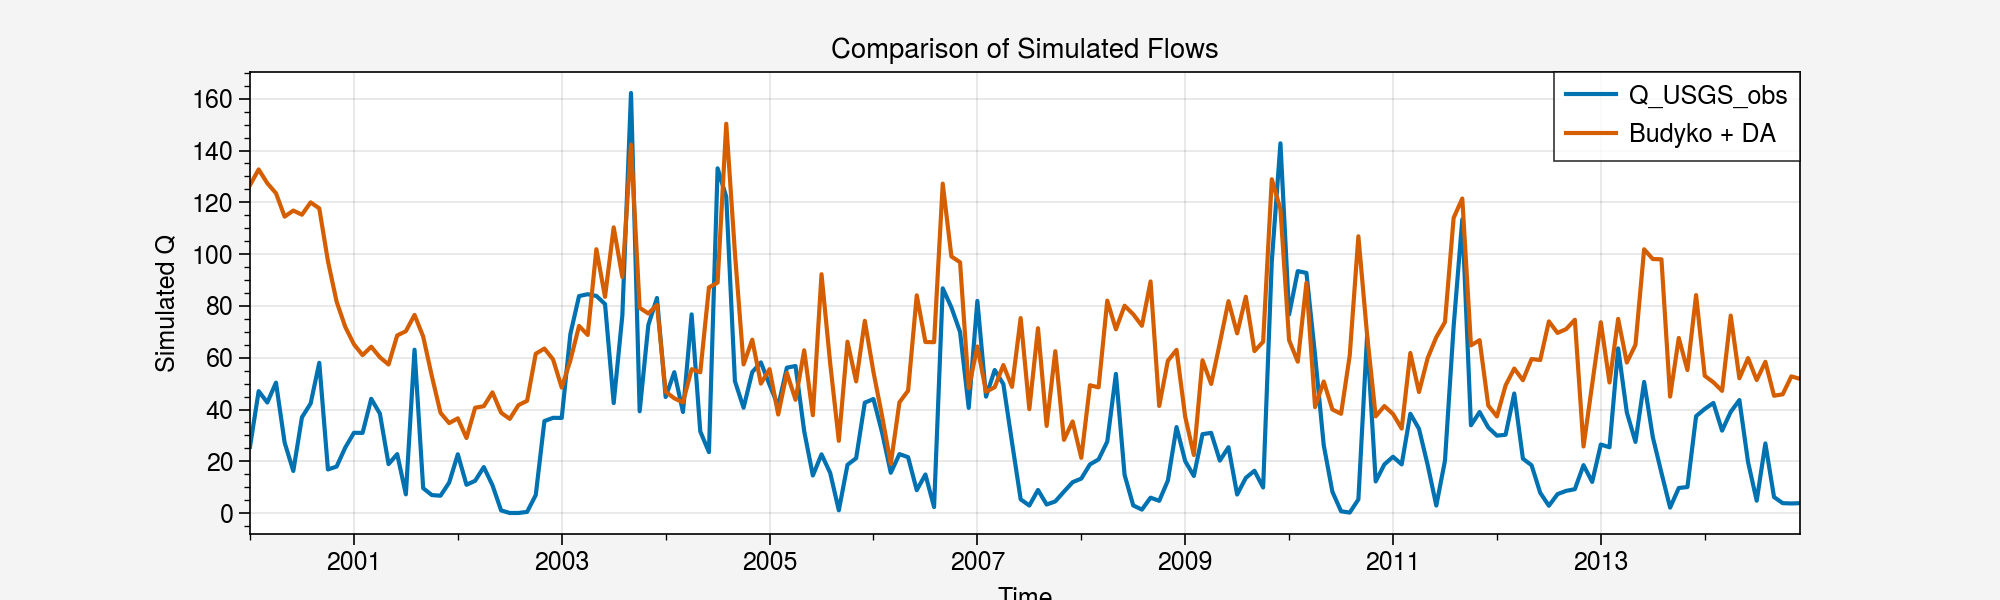

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Feather file
file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\01669520_enkf_timeseries_ET_DA.feather"
df = pd.read_feather(file_path)

df.columns
df.set_index('Date', inplace=True)
plt.figure(figsize=(10, 3))
df['Q_USGS_obs'].plot(label='Q_USGS_obs')
# df['Q_B_Q_sim'].plot(label='Base_Q_sim')

df['Q_ET_DA_Q_sim'].plot(label='Budyko + DA')
plt.xlabel('Time')
plt.ylabel('Simulated Q')
plt.title('Comparison of Simulated Flows')
plt.legend()
plt.show()




--- Diagnostic Check ---
First 10 non-NaN Q_Base_Q_sim values:
Date
2000-01-01    126.181666
2000-02-01    133.298011
2000-03-01    129.403833
2000-04-01    126.926700
2000-05-01    119.204446
2000-06-01    122.698260
2000-07-01    122.352482
2000-08-01    128.508629
2000-09-01    127.844878
2000-10-01    108.647160
Name: Q_Base_Q_sim, dtype: float64


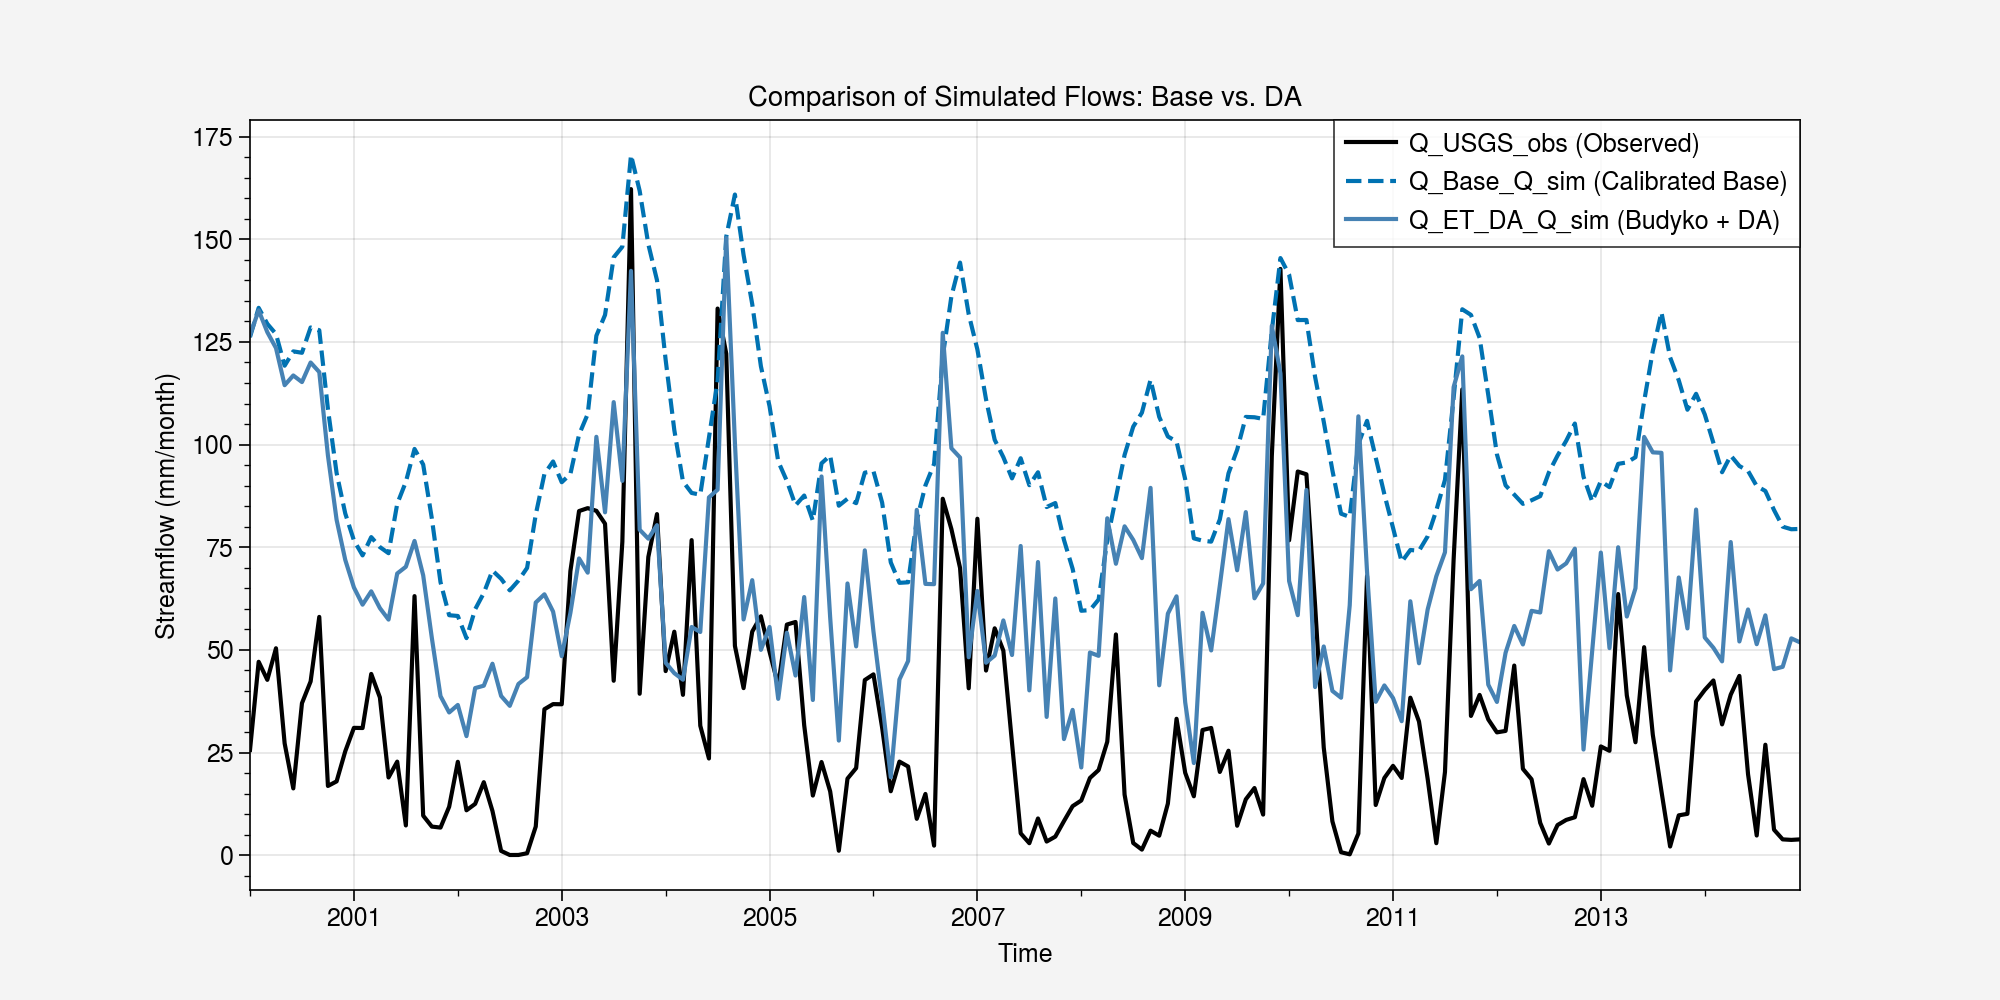

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define file path for basin 01669520
file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\01669520_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    # Load the Feather file
    df = pd.read_feather(file_path)

    df.set_index('Date', inplace=True)
    
    # --- CRITICAL CHECK: Plot the Base Simulation ---
    plt.figure(figsize=(10, 5))
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='k')
    
    # ⚠️ Check THIS line
    if 'Q_Base_Q_sim' in df.columns:
        df['Q_Base_Q_sim'].plot(label='Q_Base_Q_sim (Calibrated Base)', linestyle='--')
    else:
        print("❌ WARNING: 'Q_Base_Q_sim' column NOT found in DataFrame!")
        
    df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='steelblue')
    
    # Print the first few non-NaN values for Q_Base_Q_sim for quick inspection
    print("\n--- Diagnostic Check ---")
    if 'Q_Base_Q_sim' in df.columns:
        print(f"First 10 non-NaN Q_Base_Q_sim values:\n{df['Q_Base_Q_sim'].dropna().head(10)}")
    
    
    plt.xlabel('Time')
    plt.ylabel('Streamflow (mm/month)')
    plt.title('Comparison of Simulated Flows: Base vs. DA')
    plt.legend()
    plt.grid(True)
    plt.show()